# The Strats For Stats: Discovering Competitive Roles in Pokémon VGC
<i>Gotta cluster 'em all!</i>

# Abstract

<div style="text-align: justify;">
Pokémon battles are turn-based strategic contests in which players aim to reduce an opponent’s team to zero Hit Points (HP). The competitive format, standardized through the Pokémon Video Game Championships (VGC), establishes regulated rulesets that transform the game into a structured, probabilistic, and combinatorial decision environment. Players must continuously anticipate opponents’ actions and optimize decisions under uncertainty, making competitive Pokémon a practical example of applied game theory.
</div>

</br>
<div style="text-align: justify;">
Each Pokémon’s performance is determined by six core attributes (i.e. HP, Attack, Defense, Special Attack, Special Defense, and Speed) derived from species base stats and modified by training parameters such as Individual Values (IVs), Effort Values (EVs), and Nature. Because team composition is limited to six Pokémon [1], strategic roster construction is critical. This study applies clustering techniques to the six core attributes to identify functional archetypes, enabling data-driven team building, reducing role redundancy, and improving strategic diversity in competitive play.
</div>

# Problem Statement

<div style="text-align: justify;">
In competitive formats like Pokémon VGC, stat optimization, especially Speed and offensive/defensive balance is crucial because battles often hinge on moving first or surviving specific damage thresholds. There are no official inherent roles for each Pokémon in the game, but some competitive communities such as Smogon have made their own archetypes for Pokémon in order to classify their roles in battle. Roles are emergent properties of how stats and moves interact and it is helpful to make players think strategically, build balanced teams, avoid redundancy, and understand weaknesses.
</div>
    
</br>
<div style="text-align: justify;">
The objective is to use clustering techniques to identify natural groupings that emerge when Pokémon are clustered using only base combat stats. 
</div>
          
</br>
<div style="text-align: justify;">
<b>Scope & limitation</b>: This analysis focuses only on Pokémon combat stats that are pre-determined in the game. This will not include type, abilities, moveset, Effort Values (EVs), Individual Values (IVs), mega evolutions, Tera Type, other stat modifiers like nature or items. Moreover, all Pokémon will be used including legendary Pokémon, and the Base Form and Evolutions of each Pokémon since these are allowed in Pokémon VGC.
</div>
          
</br>
<div style="text-align: justify;">
<b>Output</b>: Cluster patterns provide Pokémon recommendations that fit a certain strategy or archetype (see example below). In terms of usability, players can select a Pokémon inside each cluster which helps prevent having redundant roles.
</div>
</br>

|Sample Generated Cluster Pattern|Player Interpretation|
|---|---|
|High Attack/Speed, low Defense|Sweeper|
|High Defense/HP, low Speed|Tank/Wall|
|Balanced stats|All Rounder|
|High Special Attack, low Attack|Special Attacker|
|High Speed, moderate offense|Utility/Finisher|

# Motivation

<div style="text-align: justify;">
As mentioned, optimizing key stats is essential since battles often depend on move order and survival thresholds. Although the game does not assign formal roles, competitive communities have defined functional archetypes based on how stats and moves interact. These emergent roles support strategic team building, reduce redundancy, and help players manage weaknesses effectively.
</div>

</br>
<div style="text-align: justify;">
With this, performing clustering will help players create their roster of Pokémon based on strategy and role preference, providing an informed decision on what to select in order to earn Championship Points (CP) to qualify for World Championship.
</div>

# Data Source

<div style="text-align: justify;">
The dataset contains a catalog of all 1025 Pokémon from Generation 1 to 9, and was scraped and processed from the PokeAPI [2][3]. Each row in the dataset corresponds to a Pokémon while the columns correspond to the features of the Pokémon which are grouped below [2]:
</div>
</br>

**Identity & Meta**
- id: The National Pokedex Number.
- name: The English name of the Pokémon.
- category: The specific species classification (e.g., "Seed Pokémon").
- generation: The generation the Pokémon first appeared (e.g., "Generation-i").
- is_legendary: Boolean (True/False) status for Legendary status.
- is_mythical:Boolean (True/False) status for Mythical status.

**Physical Traits**
- height: Height in meters.
- weight: Weight in kilograms.
- abilities: A stringified list of passive abilities (including Hidden Abilities).
- types: The Primary (and Secondary) type.(e.g., "Fire, Flying").
- habitat: The natural environment where the Pokémon resides. Note: This returns "Unknown" for Generation 4+ Pokémon, as the original games stopped recording this data after Gen 3.

**Combat Stats**
- hp, attack, defense, special_attack, special_defense, speed
    - Note that these are the Base Stats of the Pokémon.

**Type Effectiveness**
- The dataset contains 18 columns that represent the damage multiplier against specific attack types (e.g., fire, water).
    - 0.0: Immune
    - 0.5: Resistant
    - 1.0: Neutral
    - 2.0: Weak
    - 4.0: Double Weak

**Lore & Media**
- description: Pokedex flavor text, cleaned and normalized.
- evolves_from: The name of the pre-evolution (if applicable). Returns "None" if the Pokémon is a Basic stage, Baby, or has no evolution.
- cry_url: Direct link to the official OGG audio file of the Pokémon's cry.
- sprite_url: Direct link to the official sprite image.
- shiny_sprite_url: Direct link to the shiny variation sprite.

# Methodology

## Overview
</br>
<div style="text-align: center;">
<img src="Lab1.png" alt="Overview of Methodology" width="600" height="300" />
</div>

</br>
<div style="text-align: justify;">
    In order to see what natural groupings emerge when clustering Pokémon by its base combat stats, different clustering methods will be explored. First, exploratory data analysis will be conducted to understand the structure of the data. Next, the data will be preprocessed to ensure it is suitable for clustering. This includes identifying which columns are relevant for clustering, and scaling the selected features to standardize their ranges. Once preprocessing is complete, the data is clustered using different clustering methods (e.g. Representative, Hierarchical, Density) to compare results and identify meaningful groupings. Following this, the Pokémon belonging to each cluster are examined to understand the composition of the groups. Lastly, descriptive labels are assigned to each cluster based on the stats characteristics to facilitate interpretation and analysis.
</div>

</br>
<div style="text-align: justify;">
<i>
Note: The full code of the clustering methods can be viewed in the Lab1_Appendix.ipynb notebook. The Lab1.py module was created to consolidate all functions created and used for analysis.
</i>
</div>

## Step 1. Exploratory Data Analysis

<div style="text-align: justify;">
As previously mentioend, the dataset contains 1,025 rows and 40 columns where each row corresponds to a Pokémon while the columns correspond to the features of the Pokémon. It is worth noting that there are no missing values across the dataset except for the <i>evolves_from</i> column, which was previously explained in the Data Source section. Additionally, the combat stats (i.e. hp, attack, defense, special_attack, special_defense, and speed) all have an integer data type, hence data type conversion is no longer required.
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from scipy.spatial.distance import euclidean
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster
from sklearn.cluster import OPTICS, cluster_optics_dbscan
from sklearn.cluster import DBSCAN
import hdbscan

import importlib
import Lab1
importlib.reload(Lab1)

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/mnt/data/public/pokemondata/pokemon_gen9.csv')
df.head()

,id,name,category,generation,is_legendary,is_mythical,types,height,weight,abilities,...,against_bug,against_rock,against_ghost,against_dragon,against_steel,against_dark,against_fairy,cry_url,sprite_url,shiny_sprite_url
0,1,bulbasaur,Seed Pokemon,Generation-i,False,False,"grass, poison",0.7,6.9,"Overgrow, Chlorophyll (Hidden)",...,1.0,1.0,1.0,1.0,1.0,1.0,0.5,https://raw.githubusercontent.com/PokeAPI/crie...,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...
1,2,ivysaur,Seed Pokemon,Generation-i,False,False,"grass, poison",1.0,13.0,"Overgrow, Chlorophyll (Hidden)",...,1.0,1.0,1.0,1.0,1.0,1.0,0.5,https://raw.githubusercontent.com/PokeAPI/crie...,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...
2,3,venusaur,Seed Pokemon,Generation-i,False,False,"grass, poison",2.0,100.0,"Overgrow, Chlorophyll (Hidden)",...,1.0,1.0,1.0,1.0,1.0,1.0,0.5,https://raw.githubusercontent.com/PokeAPI/crie...,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...
3,4,charmander,Lizard Pokemon,Generation-i,False,False,fire,0.6,8.5,"Blaze, Solar power (Hidden)",...,0.5,2.0,1.0,1.0,0.5,1.0,0.5,https://raw.githubusercontent.com/PokeAPI/crie...,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...
4,5,charmeleon,Flame Pokemon,Generation-i,False,False,fire,1.1,19.0,"Blaze, Solar power (Hidden)",...,0.5,2.0,1.0,1.0,0.5,1.0,0.5,https://raw.githubusercontent.com/PokeAPI/crie...,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 40 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                1025 non-null   int64  
 1   name              1025 non-null   object 
 2   category          1025 non-null   object 
 3   generation        1025 non-null   object 
 4   is_legendary      1025 non-null   bool   
 5   is_mythical       1025 non-null   bool   
 6   types             1025 non-null   object 
 7   height            1025 non-null   float64
 8   weight            1025 non-null   float64
 9   abilities         1025 non-null   object 
 10  habitat           1025 non-null   object 
 11  evolves_from      484 non-null    object 
 12  description       1025 non-null   object 
 13  hp                1025 non-null   int64  
 14  attack            1025 non-null   int64  
 15  defense           1025 non-null   int64  
 16  special_attack    1025 non-null   int64  


## Step 2. Data Preprocessing

Since the focus is only on Pokémon stats, only the following columns were included in the analysis: hp, attack, defense, special_attack, special_defense, speed.

In [4]:
df_stats = df.loc[:, ['name', 'hp', 'attack', 'defense', 'special_attack', 'special_defense', 'speed']]
df_stats = df_stats.set_index('name')
df_stats

,hp,attack,defense,special_attack,special_defense,speed
name,,,,,,
bulbasaur,45,49,49,65,65,45
ivysaur,60,62,63,80,80,60
venusaur,80,82,83,100,100,80
charmander,39,52,43,60,50,65
charmeleon,58,64,58,80,65,80
...,...,...,...,...,...,...
raging-bolt,125,73,91,137,89,75
iron-boulder,90,120,80,68,108,124
iron-crown,90,72,100,122,108,98


The dataset was also scaled since the values measure different features.

In [5]:
standard_scaler = StandardScaler()
df_stats_scaled = standard_scaler.fit_transform(df_stats)

Lastly, PCA was performed to visualize the clustering of the first two principal components.

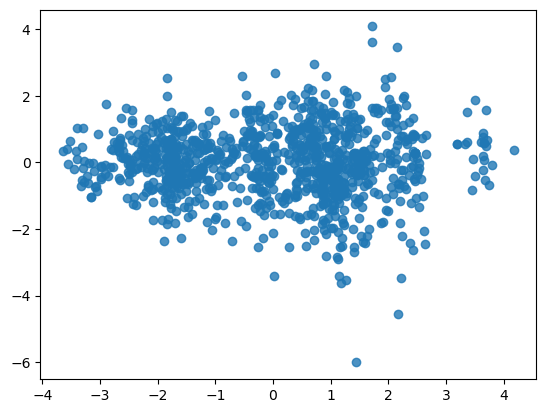

In [6]:
stats_pca = PCA(n_components=2, random_state=1337).fit_transform(df_stats_scaled)
plt.scatter(stats_pca[:, 0], stats_pca[:, 1], alpha=0.8);

## Step 3. Clustering

Representative Clustering, Hierarchical Clustering, and Density Clustering were explored to see which method performs best given the nature of the dataset.

### Representative Clustering

#### K-Means

The best value for the number of clusters using K-Means is 3 because of the following:
1. Looking at the statistics, this is the number of clusters where an elbow is observed in the SSE.
2. The scores in the Silhouette Coefficient, Gap Statistic and CH are on the higher end compared to the other values of k.

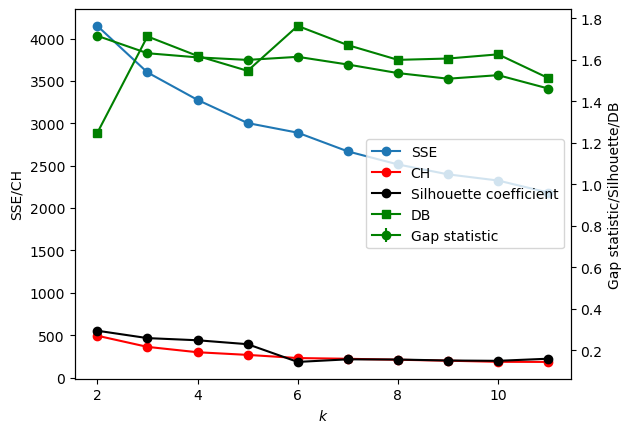

In [7]:
kmeans_plot = Lab1.cluster_range(df_stats_scaled, KMeans(random_state=1337, n_init="auto"), 2, 11)

fig, ax = plt.subplots()
Lab1.plot_internal(
    ax,
    kmeans_plot["inertias"],
    kmeans_plot["chs"],
    kmeans_plot["scs"],
    kmeans_plot["dbs"],
    kmeans_plot["gss"],
    kmeans_plot["gssds"],
);

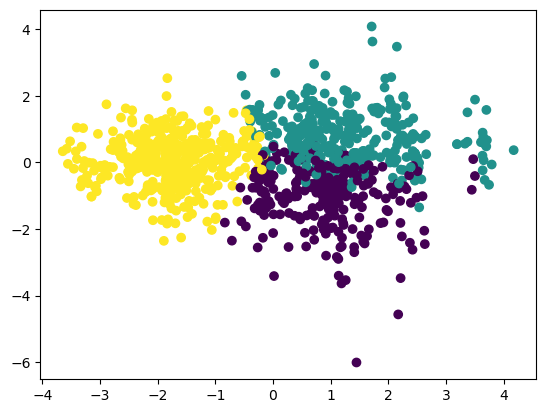

In [8]:
kmeans_stats = KMeans(n_clusters=3, random_state=1337, n_init="auto")
kmeans_predict_stats = kmeans_stats.fit_predict(df_stats_scaled)
plt.scatter(stats_pca[:, 0], stats_pca[:, 1], c=kmeans_predict_stats);

#### K-Medoids

The best value for the number of clusters using K-Medoids is 3 because of the following:
1. Looking at the statistics, this is the number of clusters where an elbow is observed in the SSE.
2. The scores in the Silhouette Coefficient, Gap Statistic and CH are on the higher end compared to the other values of k.
3. The DB score is relatively low compared to the other values of k.

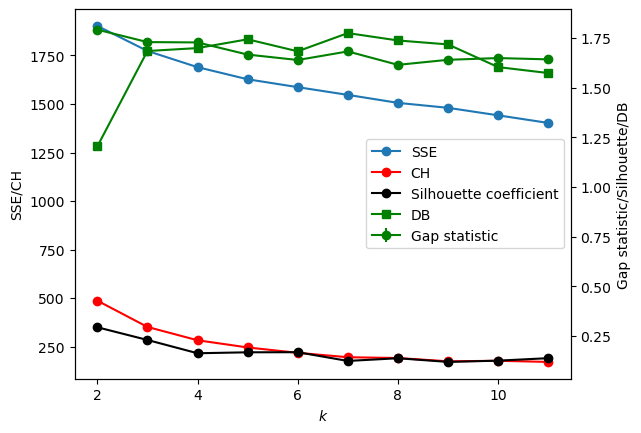

In [9]:
kmedoids_plot = Lab1.cluster_range(df_stats_scaled, KMedoids(random_state=1337, method="pam"), 2, 11)

fig, ax = plt.subplots()
Lab1.plot_internal(
    ax,
    kmedoids_plot["inertias"],
    kmedoids_plot["chs"],
    kmedoids_plot["scs"],
    kmedoids_plot["dbs"],
    kmedoids_plot["gss"],
    kmedoids_plot["gssds"],
);

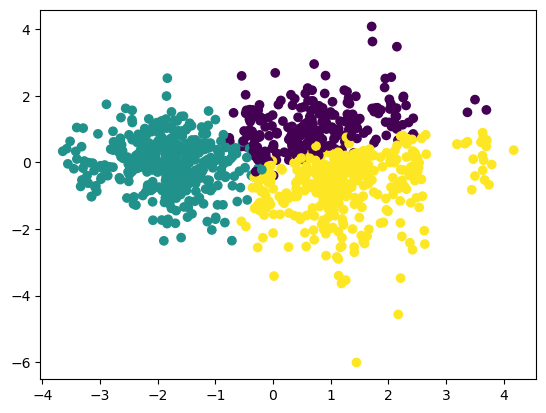

In [10]:
kmedoids_stats = KMedoids(n_clusters=3, method="pam", random_state=1337)
kmedoids_predict_stats = kmedoids_stats.fit_predict(df_stats_scaled)
plt.scatter(stats_pca[:, 0], stats_pca[:, 1], c=kmedoids_predict_stats);

### Hierarchical Clustering

#### Single Linkage

Looking at the dendogram, the best value for the number of clusters is 3 at t = 3 since this threshold is within the largest gap between merges.

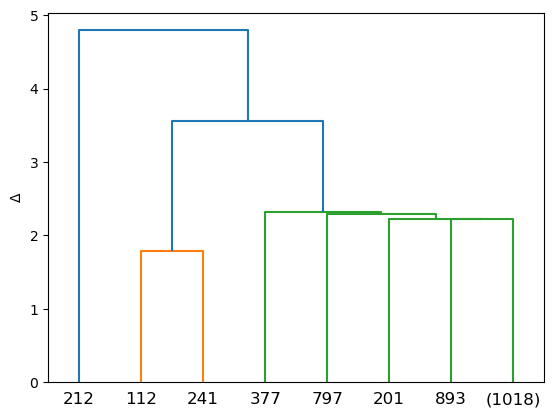

In [11]:
single_tree = linkage(df_stats_scaled, method="single")
single_tree_plot = Lab1.plot1(single_tree)

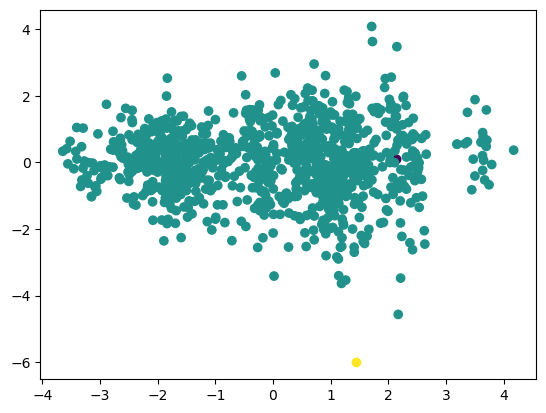

In [12]:
single_predict_stats = fcluster(single_tree, t=3, criterion="distance")
plt.scatter(stats_pca[:, 0], stats_pca[:, 1], c=single_predict_stats);

#### Complete Linkage

Looking at the dendogram, the best value for the number of clusters is 3 at t = 9 since this threshold is within the largest gap between merges.

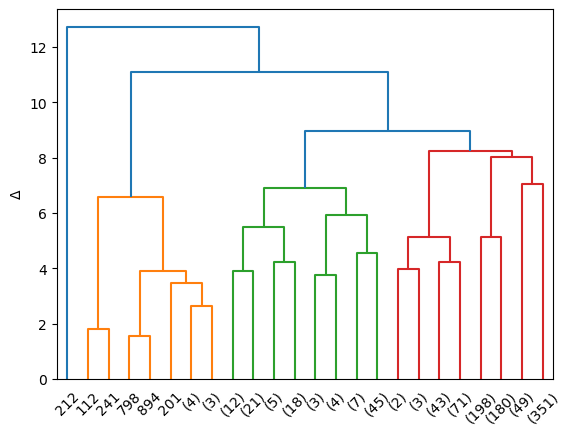

In [13]:
complete_tree = linkage(df_stats_scaled, method="complete")
complete_tree_plot = Lab1.plot1(complete_tree)

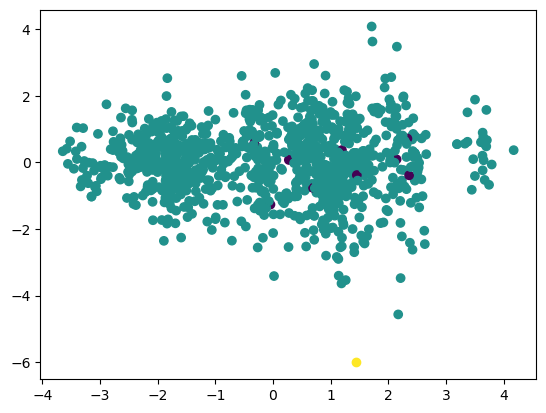

In [14]:
complete_predict_stats = fcluster(complete_tree, t=9, criterion="distance")
plt.scatter(stats_pca[:, 0], stats_pca[:, 1], c=complete_predict_stats);

#### Average Linkage

Looking at the dendogram, the best value for the number of clusters is 3 at t = 6 since this threshold is within the largest gap between merges.

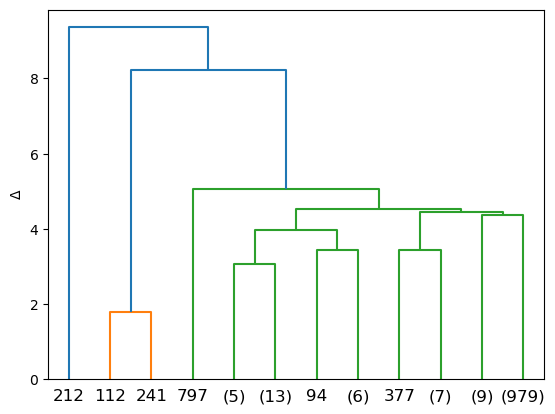

In [15]:
average_tree = linkage(df_stats_scaled, method="average")
average_tree_plot = Lab1.plot1(average_tree)

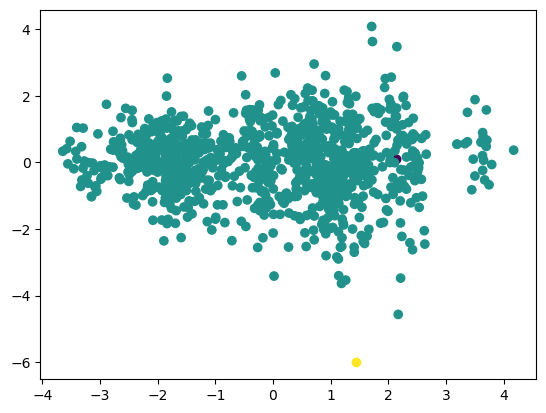

In [16]:
average_predict_stats = fcluster(average_tree, t=6, criterion="distance")
plt.scatter(stats_pca[:, 0], stats_pca[:, 1], c=average_predict_stats);

#### Ward

Looking at the dendogram, the best value for the number of clusters is 3 at t = 29 since this threshold is within the largest gap between merges.

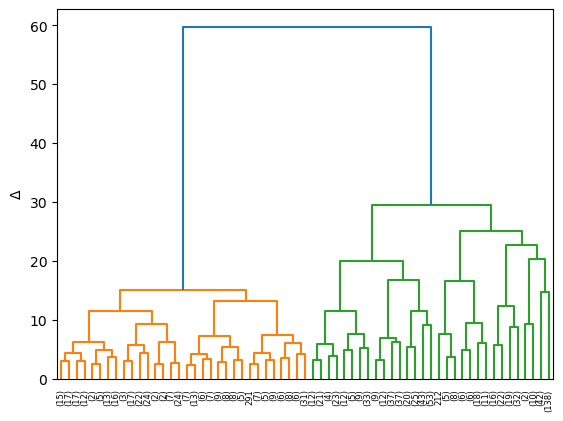

In [17]:
ward_tree = linkage(df_stats_scaled, method="ward")
ward_tree_plot = Lab1.plot1(ward_tree)

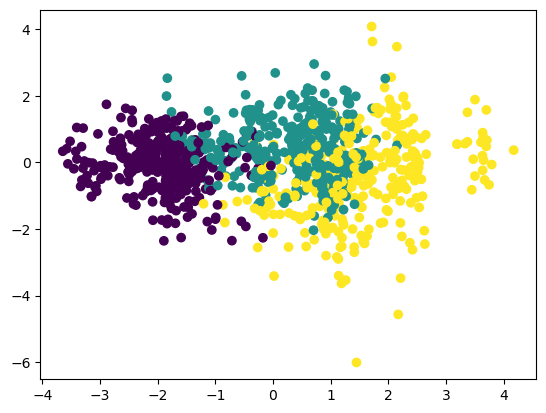

In [18]:
ward_predict_stats = fcluster(ward_tree, t=29, criterion="distance")
plt.scatter(stats_pca[:, 0], stats_pca[:, 1], c=ward_predict_stats);

### Density Clustering

#### DBSCAN

The hyperparameters used are the following:
- min_samples = 12
    - Rationale: Given that the minimum number of samples should be twice as the number of dimensions, min_samples is set to 12 since the number of dimensions is 6. 
- k = 11
    - Rationale: Given that k is min_samples - 1, this gives k a value of 11.
- $\epsilon$ = 2.9
    - Rationale: Looking at the distance vs point graph, the elbow happens around the value of 2.9. Therefore, $\epsilon$ is set to 2.9.

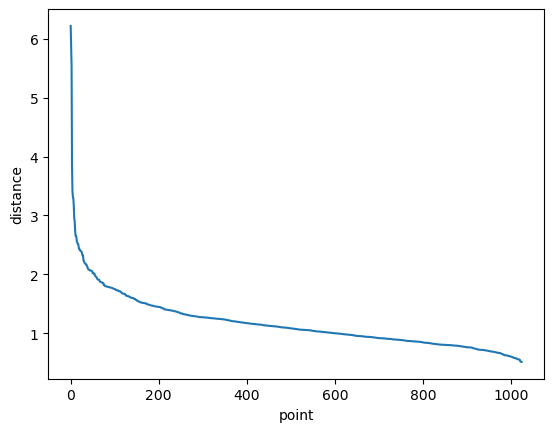

In [19]:
plt.plot(Lab1.get_kdist(11, df_stats_scaled))
plt.xlabel("point")
plt.ylabel("distance");

Number of clusters: 1
Number of noise points: 3
Number of points in the largest cluster: 1022
Number of points: 1025


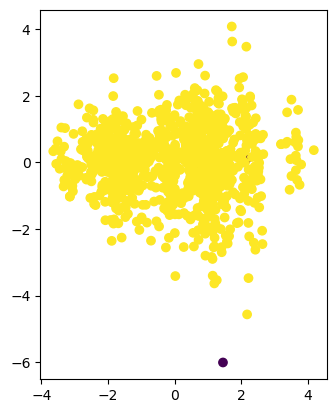

In [20]:
dbscan_stats = DBSCAN(eps=2.9, min_samples=12)
dbscan_predict_stats = dbscan_stats.fit_predict(df_stats_scaled)
plt.scatter(stats_pca[:, 0], stats_pca[:, 1], c=dbscan_predict_stats);
plt.gca().set_aspect("equal")
print("Number of clusters:", dbscan_predict_stats.max() + 1)
print("Number of noise points:", (dbscan_predict_stats == -1).sum())
print(
    "Number of points in the largest cluster:",
    np.bincount(dbscan_predict_stats[dbscan_predict_stats >= 0]).max(),
)
print("Number of points:", len(dbscan_predict_stats))

#### HDBSCAN

The hyperparameter used is min_cluster_size = 7 because this is where the splits in densities are observed whereas higher values of min_cluster_size will not show any branches.

In [21]:
hdbscan_stats = hdbscan.HDBSCAN(min_cluster_size=7, gen_min_span_tree=True)
hdbscan_stats.fit(df_stats_scaled);

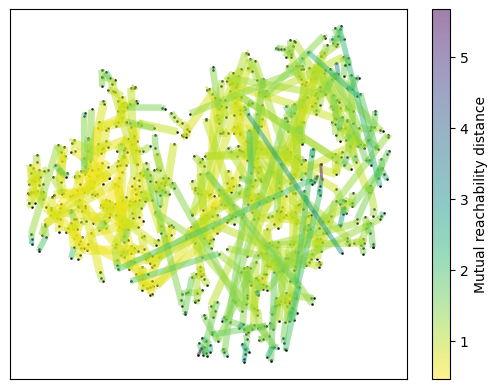

In [22]:
hdbscan_stats.minimum_spanning_tree_.plot(node_size=1);

<Axes: ylabel='distance'>

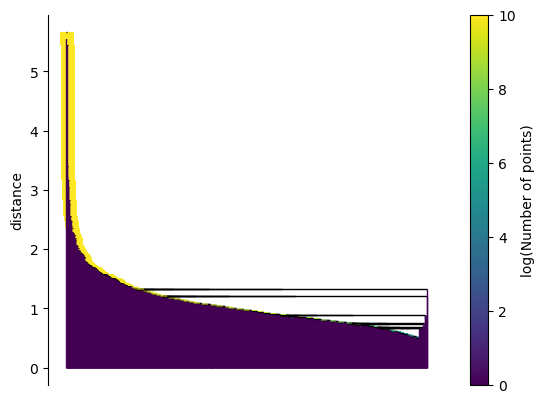

In [23]:
hdbscan_stats.single_linkage_tree_.plot()

<Axes: ylabel='$\\lambda$ value'>

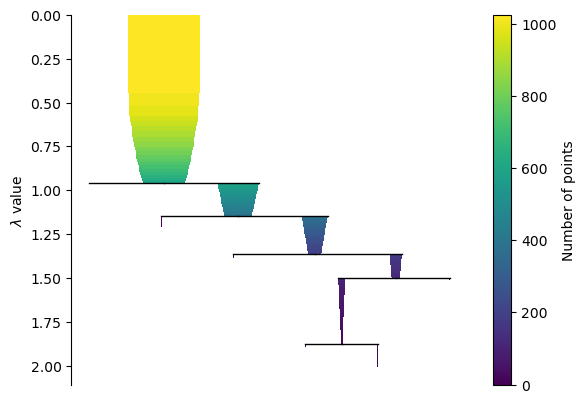

In [24]:
hdbscan_stats.condensed_tree_.plot()

Number of clusters: 2
Number of noise points: 433
Number of points in the largest cluster: 585
Number of points: 1025


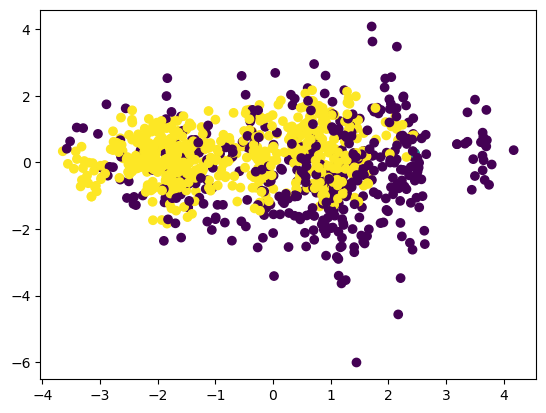

In [25]:
hdbscan_predict_stats = hdbscan_stats.fit_predict(df_stats_scaled)
plt.scatter(stats_pca[:, 0], stats_pca[:, 1], c=hdbscan_predict_stats);
print("Number of clusters:", hdbscan_predict_stats.max() + 1)
print("Number of noise points:", (hdbscan_predict_stats == -1).sum())
print(
    "Number of points in the largest cluster:",
    np.bincount(hdbscan_predict_stats[hdbscan_predict_stats >= 0]).max(),
)
print("Number of points:", len(hdbscan_predict_stats))

#### OPTICS

The hyperparameters used were min_samples = 6 and $\epsilon$ = 0.5 because setting higher values of min_samples will result in a smoother reachability plot and setting an epsilon will be difficult. 

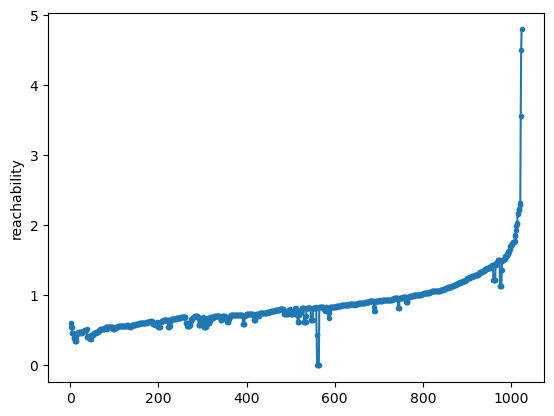

In [26]:
optics_stats = OPTICS(min_samples=6, cluster_method="dbscan")
optics_stats.fit(df_stats_scaled)
plt.plot(optics_stats.reachability_[optics_stats.ordering_], ".-")
plt.ylabel("reachability");

Number of clusters: 3
Number of noise points: 959
Number of points in the largest cluster: 30
Number of points: 1025
Silhouette score: -0.30535175752087623


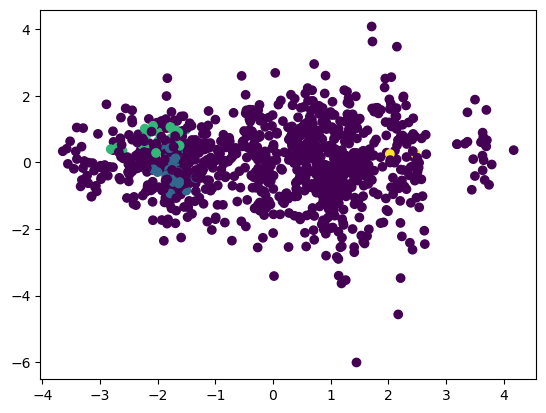

In [27]:
optics_predict_stats = cluster_optics_dbscan(
    reachability=optics_stats.reachability_,
    core_distances=optics_stats.core_distances_,
    ordering=optics_stats.ordering_,
    eps=0.5,
)
plt.scatter(stats_pca[:, 0], stats_pca[:, 1], c=optics_predict_stats);
print("Number of clusters:", optics_predict_stats.max() + 1)
print("Number of noise points:", (optics_predict_stats == -1).sum())
print(
    "Number of points in the largest cluster:",
    np.bincount(optics_predict_stats[optics_predict_stats >= 0]).max(),
)
print("Number of points:", len(optics_predict_stats))
print("Silhouette score:", silhouette_score(df_stats_scaled, optics_predict_stats))

# Results and Discussion

## Clustering Methods

<div style="text-align: justify;">
Comparing the different clustering methods, **K-Medoids will be the method of choice** in analyzing the cluster labels. With the Representative Methods, K-Medoids performed better than K-Means because the ranges for SSE and CH in K-Medoids is lower than K-Means, and the clusters made by K-Medoids appear to be more visually compact and balanced with minimal overlapping datapoints compared to K-Means. 
</div>

</br>
<div style="text-align: justify;">
Likewise, the different hierarchical methods did not perform well upon visual inspection since the clusters are not balanced, compact, and separated.
</div>

</br>
<div style="text-align: justify;">
Lastly, the different density methods did not perform well and may not provide meaningful information on the clusters. For DBSCAN, given that there are no clear regions of high density, it did not perform well in clustering as it grouped majority of the datapoints into one cluster. HDBSCAN and OPTICS were able to identify a lot of noise, however the goal of the study is to not find outliers and assign a cluster to all Pokémon.
</div>

## Cluster Labels

Using the clustering results from K-Medoids, below are the different Pokémon grouped into the 3 clusters identified. The results below are capped to 6 to show a snippet. Overall, Cluster 0 has 246 Pokémon, Cluster 1 has 383 Pokémon, and Cluster 2 has 396 Pokémon.

In [28]:
Lab1.pokemon_cluster(df_stats, kmedoids_predict_stats, 6)

Cluster 0: ['charmeleon', 'charizard', 'beedrill', 'pidgeot', 'raticate', 'fearow']
Cluster 1: ['bulbasaur', 'ivysaur', 'charmander', 'squirtle', 'wartortle', 'caterpie']
Cluster 2: ['venusaur', 'blastoise', 'sandslash', 'nidoqueen', 'clefable', 'vileplume']


The stats for each cluster are also plotted for easier comparison.

**Stats for Cluster 0**

Looking at the stats for Cluster 0, the Pokémon in this group tend to have a high attack/speed, and a low defense/special defense. These suggest that the role for this cluster is a **Sweeper** given that it focuses on attacks. It is also worth noting that the composition of the cluster includes the first evolution and the second evolution of the Pokémon.

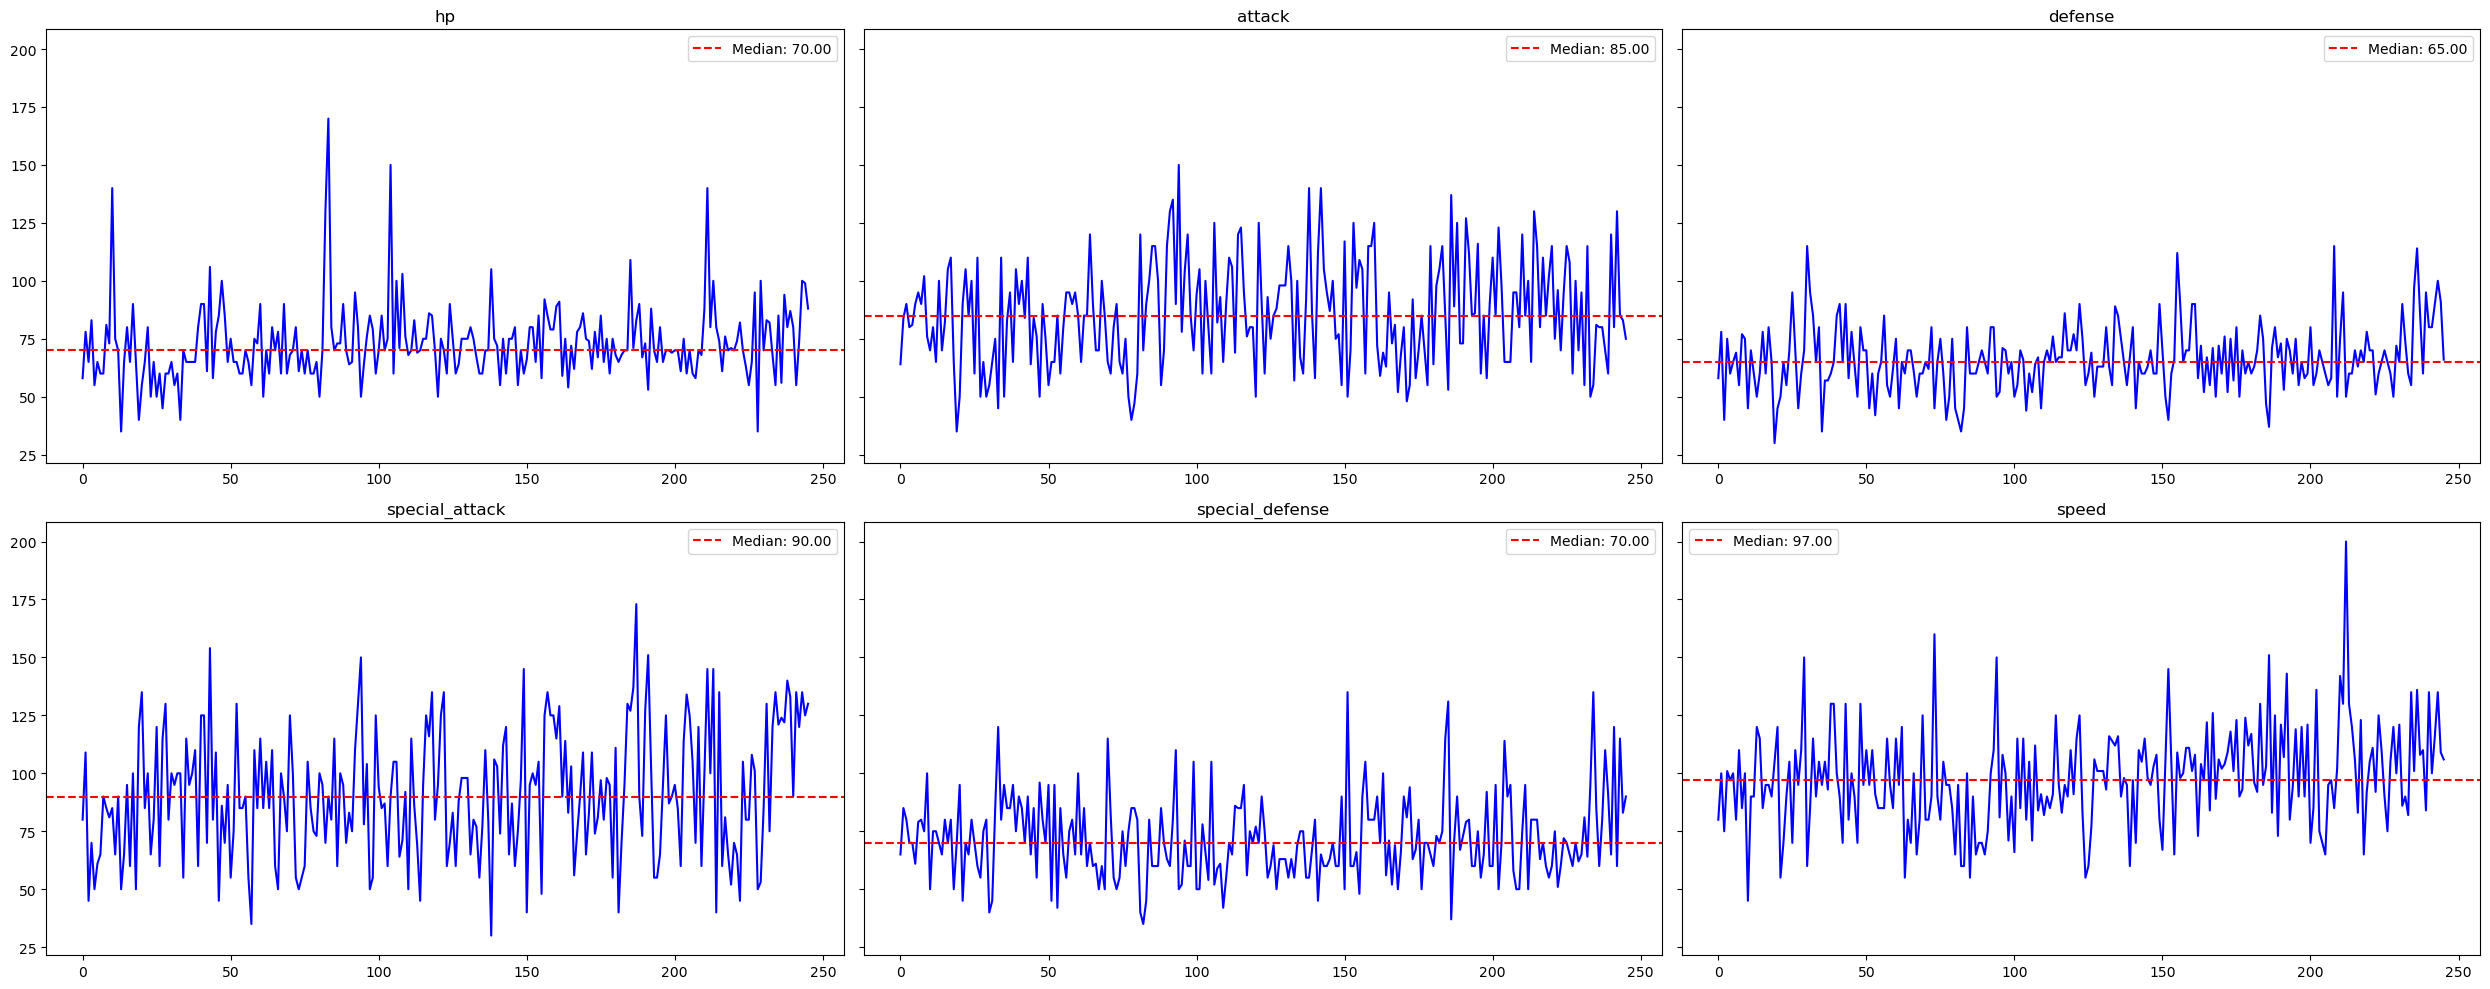

In [29]:
cluster_0 = Lab1.pokemon_df(df_stats, kmedoids_predict_stats, 0)
Lab1.plot_pokemon_stats(cluster_0)

**Stats for Cluster 1**

Looking at the stats for Cluster 1, the Pokémon in this group tend to have similar scores for hp, attack, defense, special attack, special defense, and speed. It is worth noting however that these scores are low relative to Cluster 0 and Cluster 2. These suggest that the role for this cluster is an **All Rounder/Support** given the balanced nature of the stats. It is also worth noting that the composition of the cluster includes the Base Form and the first evolution of the Pokémon.

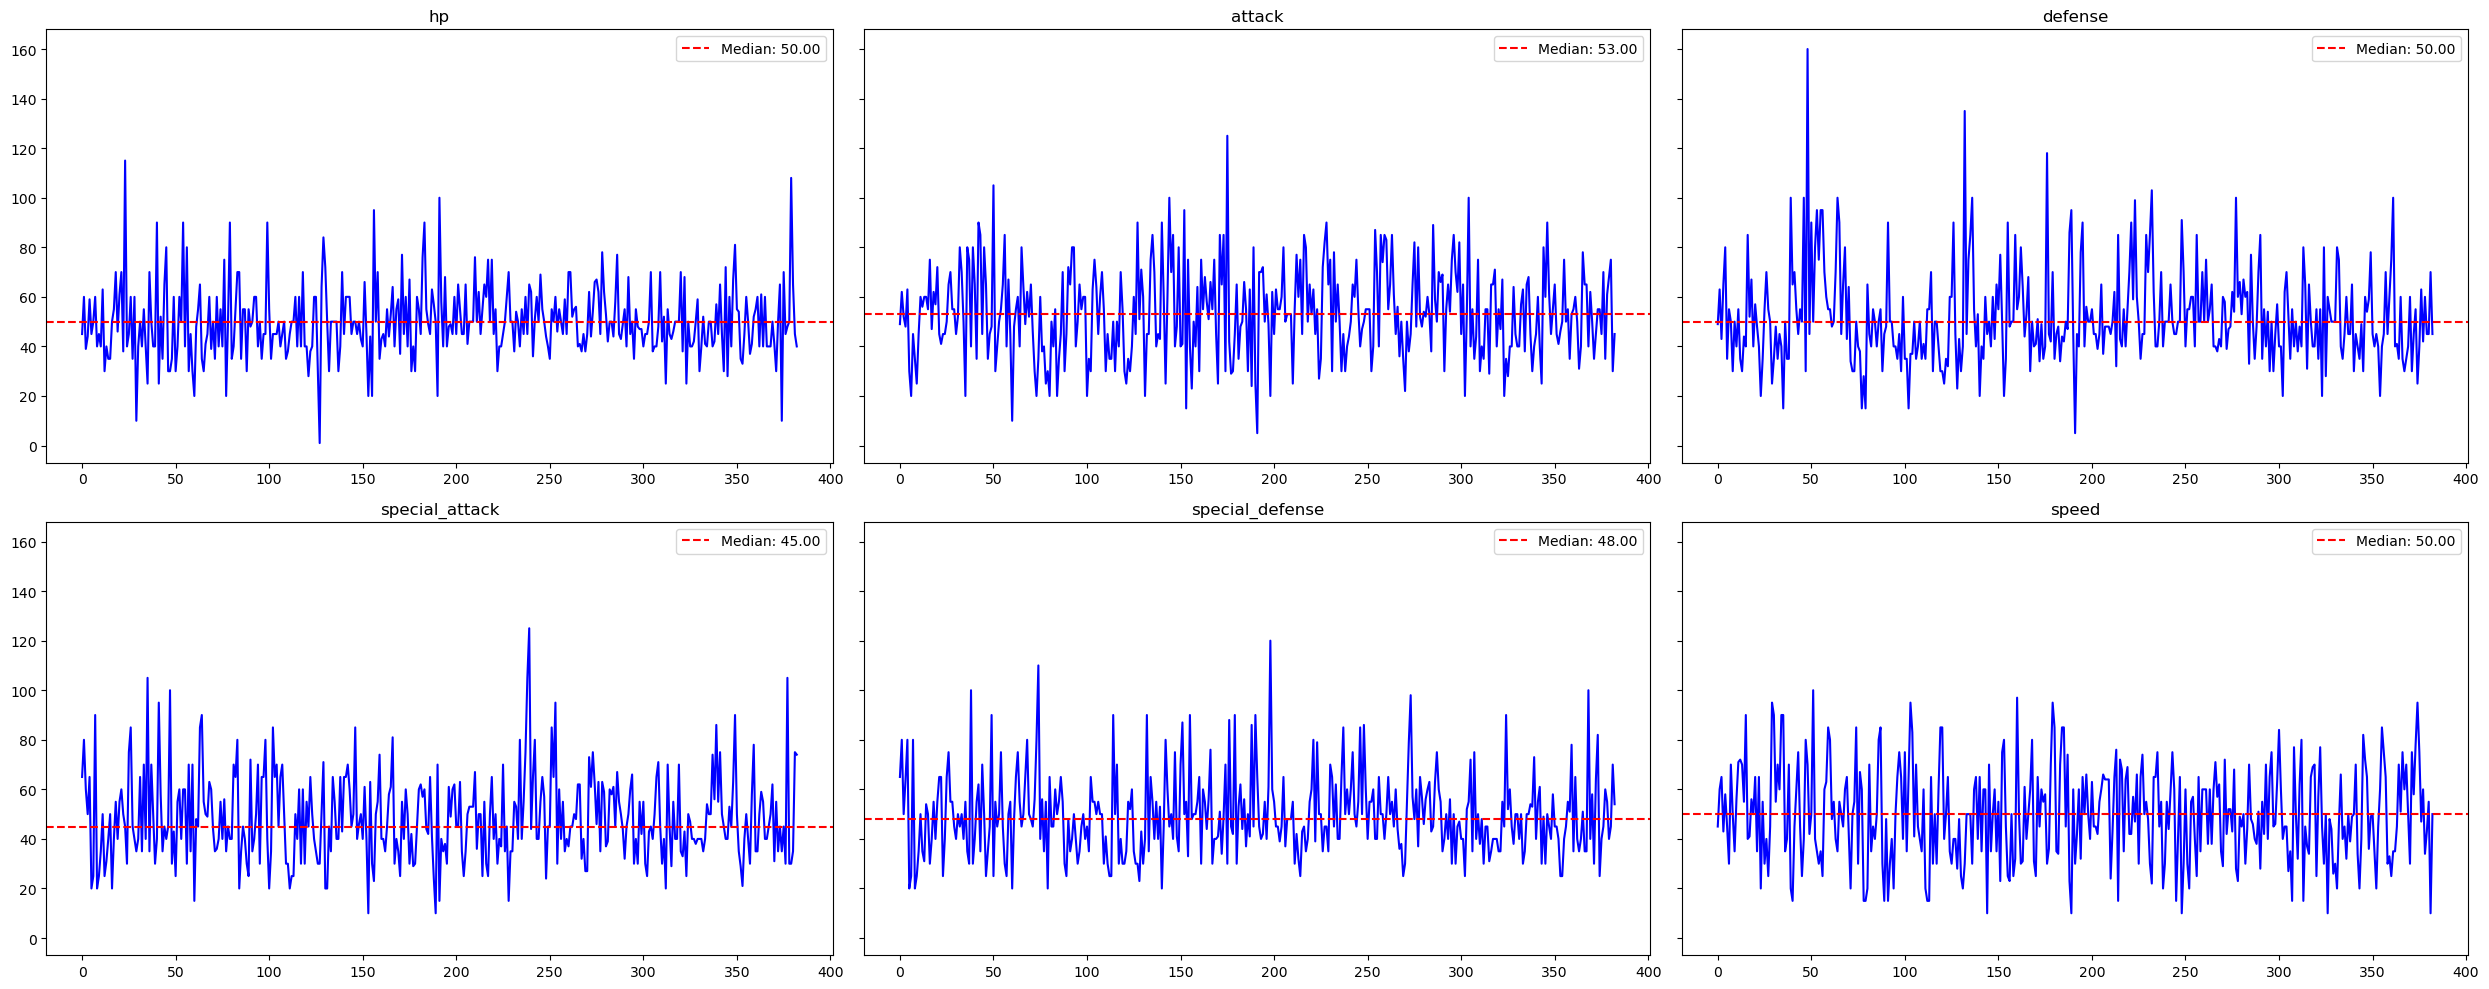

In [30]:
cluster_1 = Lab1.pokemon_df(df_stats, kmedoids_predict_stats, 1)
Lab1.plot_pokemon_stats(cluster_1)

**Stats for Cluster 2**

Looking at the stats for Cluster 2, the Pokémon in this group tend to have a low speed/special attack, but high hp/attack/defense/special defense. These suggest that the role for this cluster is a **Physical Attack Tank** given that it focuses on having a high defense and hp, all while having strong normal attacks. It is also worth noting that the composition of the cluster includes some legendary Pokémon and the first and second evolution of the Pokémon.

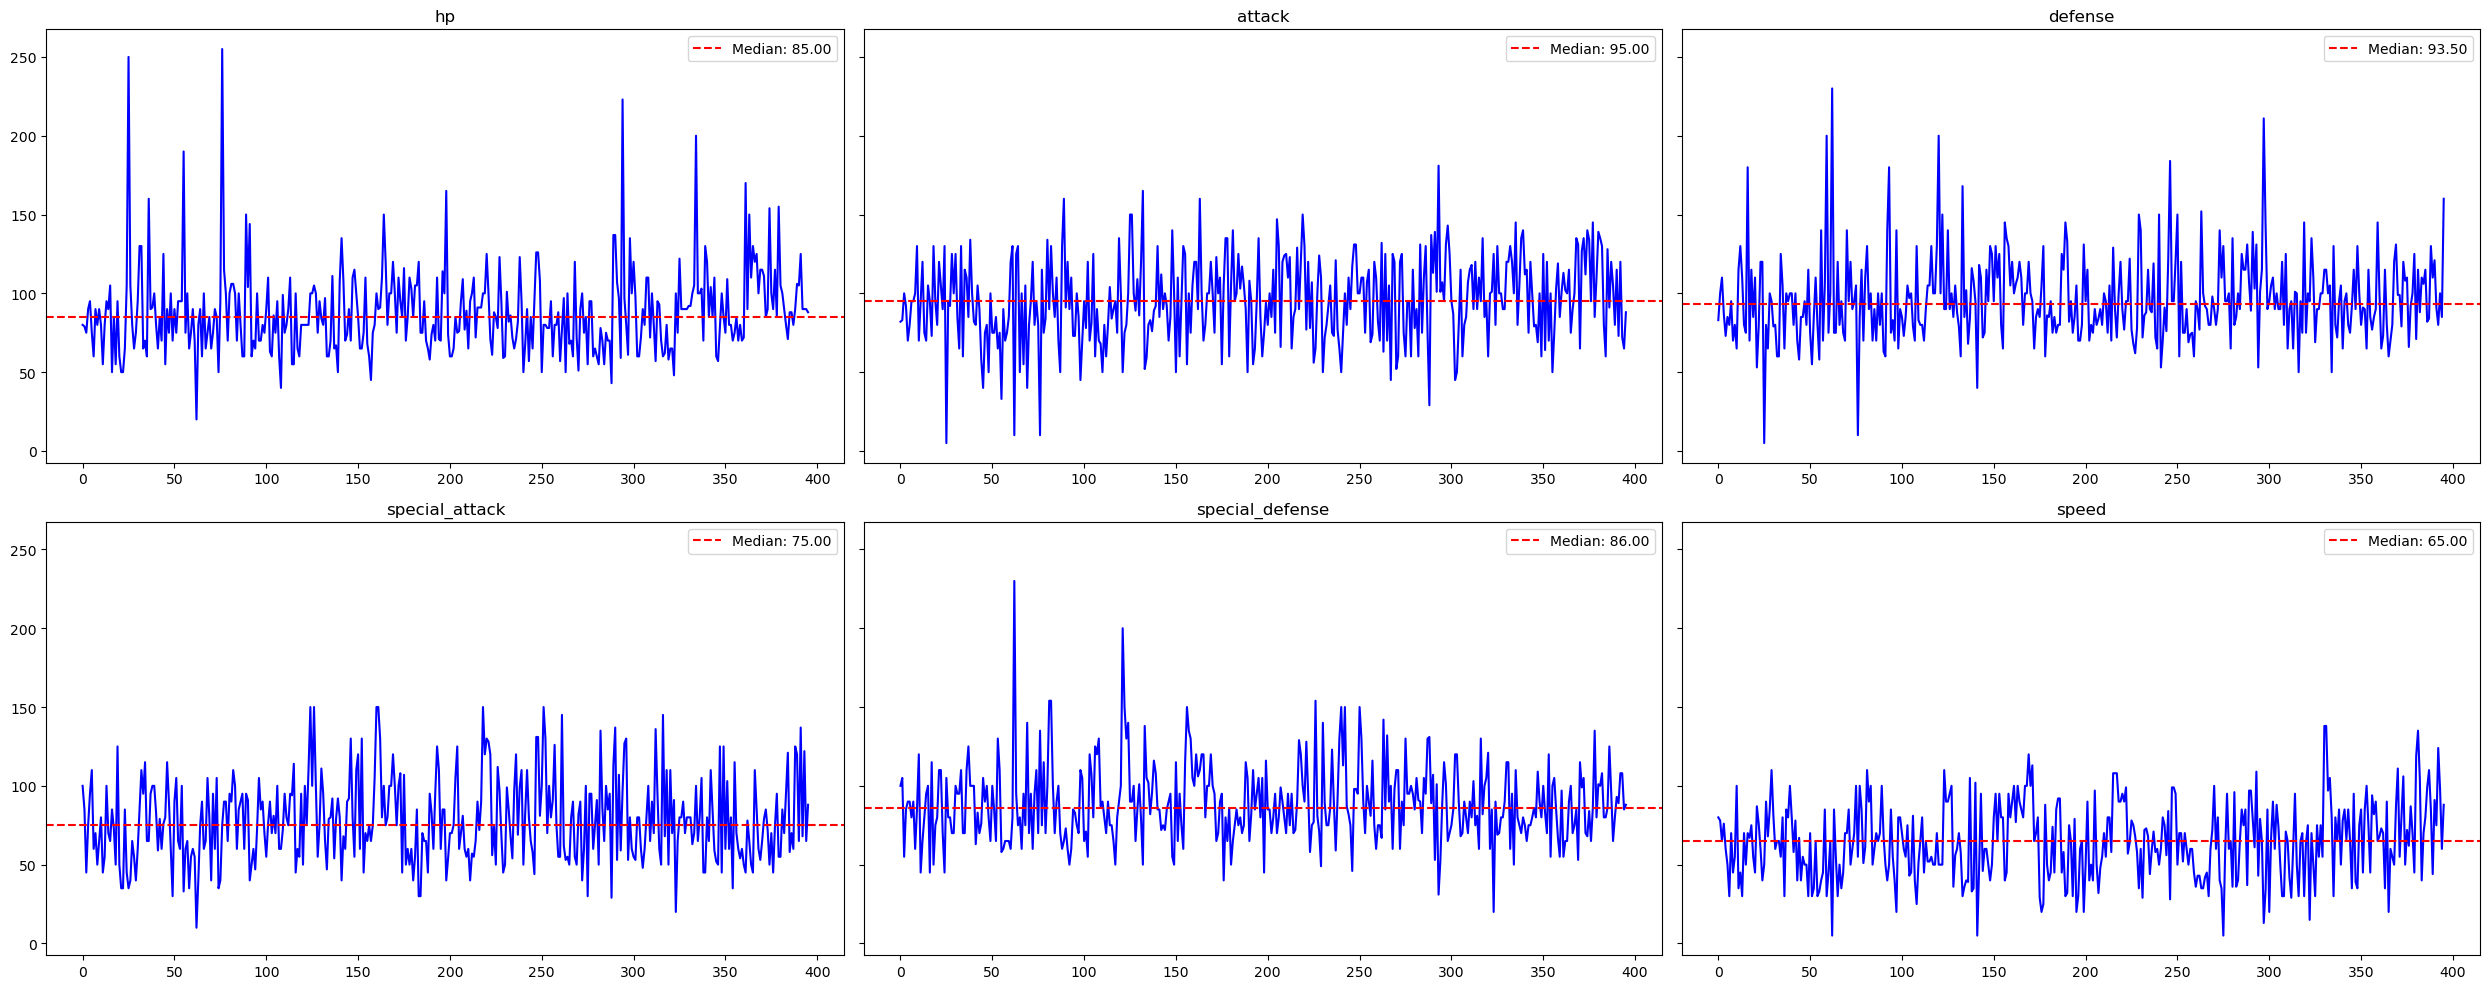

In [31]:
cluster_2 = Lab1.pokemon_df(df_stats, kmedoids_predict_stats, 2)
Lab1.plot_pokemon_stats(cluster_2)

To summarize, below are the cluster labels translated to Pokémon roles:

|Cluster Number|Cluster Pattern|Player Interpretation|
|---|---|---|
|Cluster 0|high attack/speed, low defense/special defense|Sweeper|
|Cluster 1|similar scores for hp, attack, defense, special attack, special defense, and speed|All Rounder/Support|
|Cluster 2|high hp/attack/defense/special defense, low speed/special attack|Physical Attack Tank|

# Conclusion

<div style="text-align: justify;">
The clustering results indicate that the algorithm naturally separated restricted-tier powerhouses from support and developmental Pokémon.
</div>

</br>
<div style="text-align: justify;">
Instead of forming one smooth distribution of balanced stats, the data organizes into three distinct competitive archetypes such as Physical Attack Tank, Sweepers, and lower-stat Support units. This structure explains why speed control moves like Tailwind, Trick Room, and Icy Wind are extremely important in VGC meta as they allow teams to shift interactions between clusters rather than simply outscaling average stats.
</div>

</br>
<div style="text-align: justify;">
A competitive team should be constructed around Cluster 2 as the primary win condition while leveraging Cluster 0 to apply offensive pressure and tempo advantage. Cluster 2 Pokémon, as bulky powerhouses, should form the core of the team because they survive hits, switch efficiently, and define the team’s identity; they are best positioned as late-game closers or central damage anchors. However, their lower speed often requires support, making Cluster 1 essential for enabling favorable board states through speed control, disruption, or pivoting—these Pokémon do not win through raw stats but through positional advantage. The Pokemon in Cluster 1 are typically utilized for movesets that set special conditions rather than stat advantage. Cluster 0 should be used strategically to pressure opponents early, threaten immediate knockouts, and force defensive responses, particularly in hyper offense builds where first-move advantage is critical. 
</div>
</br>
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
|Cluster Number|Role Type|Team Function|
|---|---|---|                                                               
|Cluster 0|Sweeper|Early-game offense|
|Cluster 1|All Rounder/Support|Setup & positioning|
|Cluster 2|Physical Attack Tank|Late-game closer|
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  
</br>
<div style="text-align: justify;">
Overall, optimal team construction balances these three clusters: Cluster 1 creates the conditions, and Cluster 0 destabilizes the opponent to open winning lines, then Cluster 2 secures victory.
</div>

# Recommendations

<div style="text-align: justify;">
To rigorously validate and operationalize the clustering results for competitive VGC insights, a Chi-square test of independence can be conducted to determine whether role type is significantly associated with the use of a Pokémon in tournaments, thereby assessing whether identified role types meaningfully influence competitive selection. Next, incorporate win rate as a target variable and use the role type as a feature within a predictive modeling framework (e.g., gradient boosting) to evaluate their impact on VGC viability and performance outcomes. 
</div>

</br>
<div style="text-align: justify;">
By including role type alongside individual stat features, the model can estimate each Pokémon’s win rate potential, and SHAP can be used to identify the features contributing to the win rate to further enrich the analysis.
</div>

# References

[1] https://www.pokemon.com/static-assets/content-assets/cms2/pdf/play-pokemon/rules/play-pokemon-vg-team-list-2023.pdf

[2] https://www.kaggle.com/datasets/elroytan/pokemondata

[3] https://pokeapi.co/